<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Team SPLIT - Leaf Image Classification</h1>
</div>

<div style="
    background-image: url('https://thumbs.dreamstime.com/b/green-tropical-plants-leaves-bush-background-chiang-mai-thailand-amphoe-mueang-southeastasia-asia-372709541.jpg');
    background-size: cover;
    background-position: center;
    width: 100%;
    height: 400px;
    display: flex;
    justify-content: center;
    align-items: center;
    color: white;
    font-size: 2em;
    font-weight: bold;
">
</div>

___
# ***Main idea of the Notebook***
___
In this notebook, we focused on creating the best model for recognizing leaf images. Instead of blindly testing random models or hyperparameters, we asked:
“What kind of models and techniques actually fit this dataset?”

- We explored how shadows, brightness, and leaf shape affect model performance.
- We compared preprocessing techniques to handle image quality problems.
- We carefully selected the right transfer learning models based on the image size, dataset scale, and problem type.
- We experimented with different dense layers and fine-tuning strategies to squeeze out every bit of accuracy we could.

This is not just training models — this is smart, data-driven modeling.

---
## 1. ***Problem Statement***
---

-  We are tasked with developing a machine learning model to classify different types of leaves based on their images. This involves designing both a custom model from scratch and utilizing a pretrained model to effectively learn and recognize the distinguishing visual patterns and features associated with each leaf class.
---
## 2. ***Our Working***
---

-  We are using a dataset containing images of leaves with various situations . Our approach involves training a deep learning model on this dataset to classify each image into one of the disease categories. By analyzing the patterns and features in the images, the model can learn to differentiate between  leaves, aiding in the detection of plant types.

<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;">  1 | Importing The Libraries</h1>
</div>

In [ ]:
import os, cv2, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

def set_random_seeds(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

set_random_seeds(42)

<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;"> 2 | Loading and Visualising</h1>
</div>

In [ ]:
train_df = pd.read_csv('/kaggle/input/leaf-wise-mulberry-classification/train.csv')
x_train, x_val, y_train, y_val = train_test_split(train_df.iloc[:, 0], train_df.iloc[:, 1], test_size=0.185, random_state=42)

___
# Showing image distribution across classes
___

In [ ]:
plt.figure(figsize=(8, 4),facecolor='black')

ax = sns.countplot(y="label", data=train_df) #this is the countplot plot shows amount of images fairly

ax.set_facecolor('black')  # axes panel color is black
ax.tick_params(colors='green')  # tick labels 
ax.yaxis.label.set_color('green')  # y-axis label
ax.xaxis.label.set_color('green')  # x-axis label
ax.title.set_color('green')        # title
plt.grid(True)      

plt.tight_layout()
plt.show()

___
#  Show sample image in each class (to observe the images we are dealing with):
___

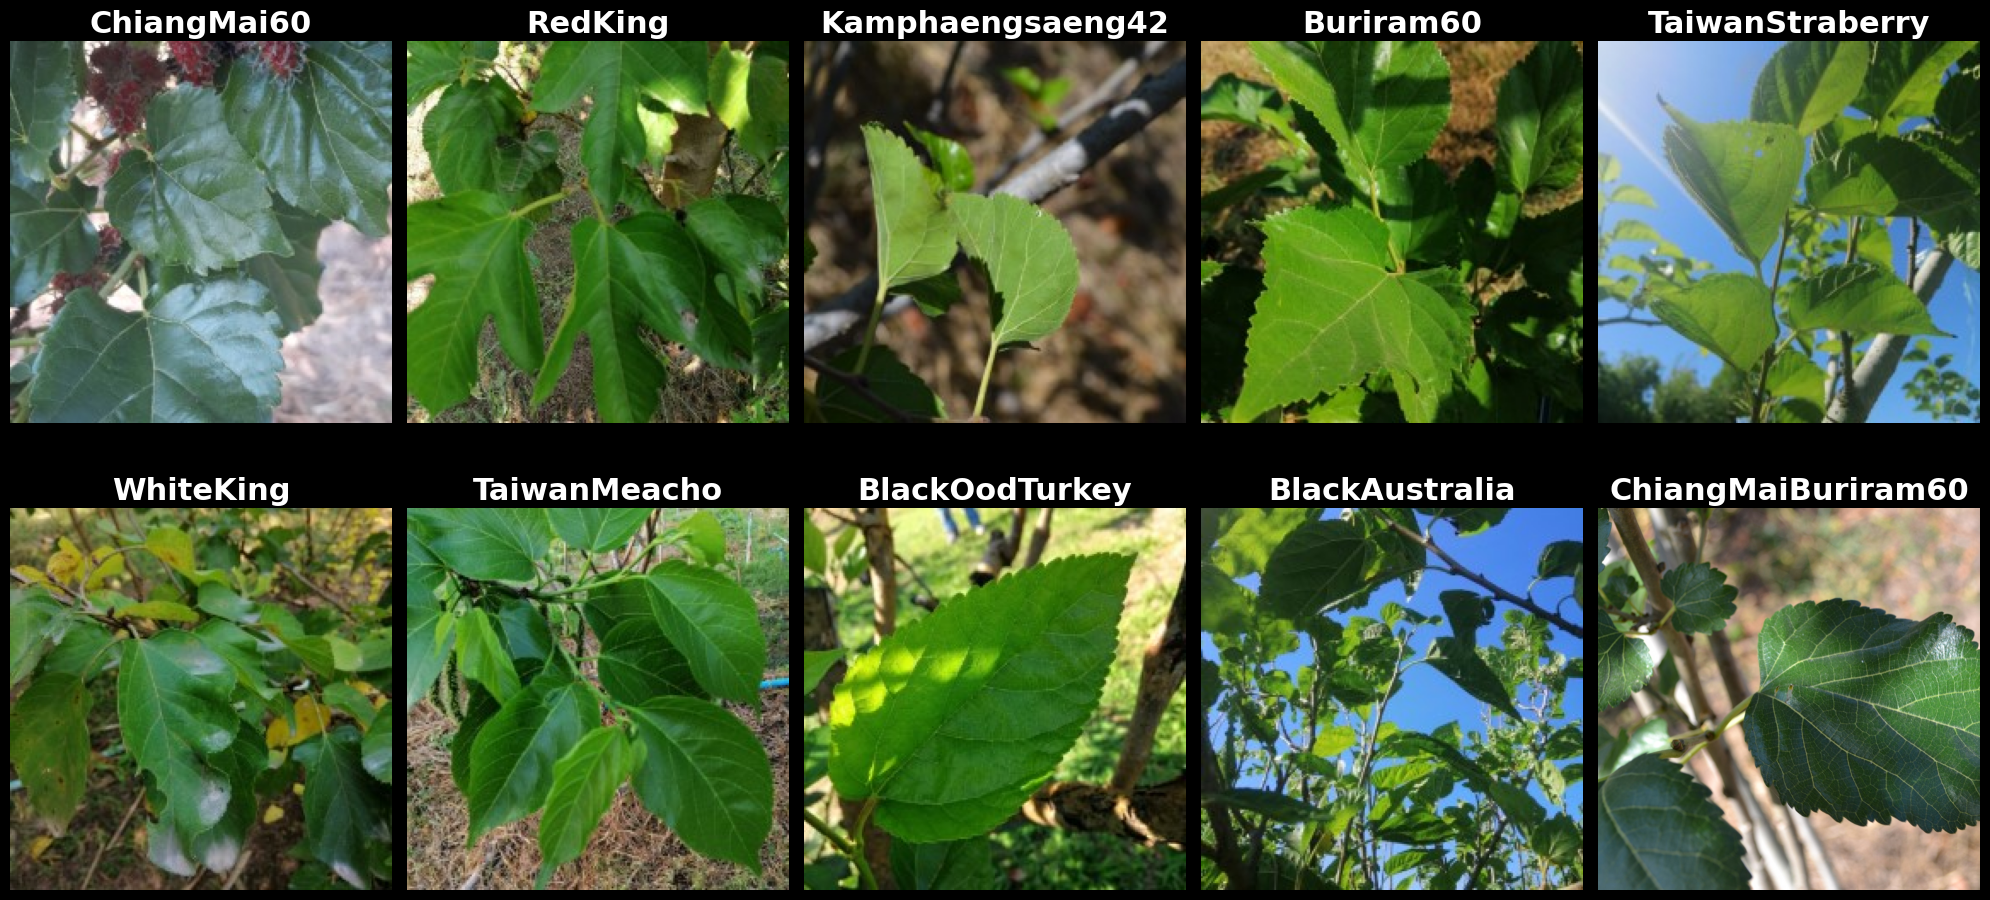

In [24]:
import PIL.Image as Image

fig, axes = plt.subplots(2, 5, figsize=(20, 10), facecolor='black')  # black background
axes = axes.ravel()

for i, cls in enumerate(train_df['label'].unique()): 
    sample_file = train_df[train_df['label'] == cls].sample(n=1)['path'].values[0]
    img = Image.open(sample_file)

    axes[i].imshow(img)
    axes[i].set_title(f'{cls}', fontdict={'fontsize': 22, 'fontweight': 'bold', 'color': 'white'})  # white text
    axes[i].axis('off')  
    axes[i].set_facecolor('grey')  # grey axes background

plt.tight_layout()
plt.show()

<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;"> 3 | Preprocessing the Data</h1>
</div>

___
# Label Encoding
___
- Label Encoding is used to change string values of label and turn it into numbers that are easier for CNN to understand using softmax layer

In [33]:
enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_val = enc.transform(y_val)

num_classes = len(enc.classes_)
y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)

train_data = pd.DataFrame({
    'filename': x_train.values,
    'label': enc.inverse_transform(np.argmax(y_train, axis=1))
})
val_data = pd.DataFrame({
    'filename': x_val.values,
    'label': enc.inverse_transform(np.argmax(y_val, axis=1))
})

ValueError: y should be a 1d array, got an array of shape (3030, 10) instead.

___
# GLOBAL SETTINGS
___
- Settings to regulate image preprocessing and model training

In [32]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 12
SEED = 42

___
# IMAGE GENERATORS
___
- Image Generator to increase situations where the model trains on a differrent type of images

In [30]:
# 5. IMAGE GENERATORS
# ===============================
def create_generators(train_df, val_df, train_datagen, val_datagen):
    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        class_mode='categorical',
        shuffle=True,
        batch_size=BATCH_SIZE,
        seed=SEED
    )
    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        class_mode='categorical',
        shuffle=False,
        batch_size=BATCH_SIZE
    )
    return train_gen, val_gen

In [ ]:
def preprocess_images_default(train_df, val_df):
    datagen_train = ImageDataGenerator(
        rescale=1./255,
        rotation_range=25,
        width_shift_range=0.12,
        height_shift_range=0.12,                                   #
        zoom_range=0.12,
        shear_range=8,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    datagen_val = ImageDataGenerator(rescale=1./255)
    return create_generators(train_df, val_df, datagen_train, datagen_val)

#################################################################################################################

# 3. Histogram Equalization
#is a technique used in image processing to process the shadows in the images provided in the dataset
def histogram_equalization(img):
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

def preprocess_images_shadow(train_df, val_df):
    """Improved shadow-resistant preprocessing with CLAHE and balanced augmentations."""

    def shadow_preprocess(img):
        img = tf.keras.preprocessing.image.img_to_array(img)
        img = cv2.resize(img, IMG_SIZE[::-1])

        # CLAHE for better shadow and highlight handling
        img_yuv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2YUV)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_yuv[:, :, 0] = clahe.apply(img_yuv[:, :, 0])
        img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

        return img.astype('float32') / 255.0

    datagen_train = ImageDataGenerator(
        preprocessing_function=shadow_preprocess,
        brightness_range=[0.85, 1.15],   # subtle brightness adjustment
        zoom_range=0.18,
        width_shift_range=0.12,
        height_shift_range=0.12,
        rotation_range=12,               # moderate rotation
        shear_range=5,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    datagen_val = ImageDataGenerator(preprocessing_function=shadow_preprocess)

    return create_generators(train_df, val_df, datagen_train, datagen_val)



#################################################################################################################


def preprocess_images_colorboost(train_df, val_df):
    """Handles color diversity while keeping key color info for leaves."""

    def color_boost_func(img):
        img = tf.keras.preprocessing.image.img_to_array(img)
        img = cv2.resize(img, IMG_SIZE[::-1])

#Convert to HSV to adjust hue/saturation slightly (color jitter)
        img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        img_hsv[:, :, 1] = np.clip(img_hsv[:, :, 1] * np.random.uniform(0.9, 1.1), 0, 255)
        img_hsv[:, :, 2] = np.clip(img_hsv[:, :, 2] * np.random.uniform(0.9, 1.1), 0, 255)
        img = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

        # Standardization: make colors more consistent
        img = tf.image.per_image_standardization(img).numpy()
        return img

    datagen_train = ImageDataGenerator(
        preprocessing_function=color_boost_func,
        zoom_range=0.15,
        width_shift_range=0.08,
        height_shift_range=0.08,
        rotation_range=15,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    datagen_val = ImageDataGenerator(preprocessing_function=color_boost_func)

    return create_generators(train_df, val_df, datagen_train, datagen_val)

In [ ]:
trainshadow,valshadow=preprocess_images_shadow_resistant(train_data,val_data)

# ***Preprocessing the Dataset***
# We tried multiple preprocessing styles — from simple image scaling to advanced shadow-resistant techniques.

Shadows were messing with the model’s predictions! They made leaves look different depending on lighting. So we applied:

- histogram_equalization – balances brightness across the image.

- shadow_preprocess_function – gives the model more “shadow-proof” vision.

- Data augmentation – like random zoom, shift, and rotation, to help generalize better.

- We used shadows due to many leaf images contain shadows that can confuse the model

- We used Histogram equalization to turn up the contrast smartly. It spreads out pixel intensity values so the image doesn't look too dull or too flat.

In [ ]:
# Create the generators
train_gen, val_gen = preprocess_images_shadow(train_data, val_data)

# Get a batch of images and labels
images, labels = next(train_gen)



plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {np.argmax(labels[i])}")
    plt.axis('off')

plt.suptitle("Sample Augmented Images (Shadow-Resistant)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Create the generators
train_gen, val_gen = preprocess_images_colorboost(train_data, val_data)

# Get a batch of images and labels
images, labels = next(train_gen)



plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {np.argmax(labels[i])}")
    plt.axis('off')

plt.suptitle("Sample Augmented Images (Shadow-Resistant)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;">4 | Training The Model</h1>
</div>

___
# 1. CNN Custom Model
___
- A model built to handle complex data

<img src='https://www.researchgate.net/publication/321475443/figure/fig3/AS:670729951518723@1536925890638/Graphical-representation-of-the-convolutional-neural-network-used-in-experiments.ppm'>

# The Model Uses a Mix of layers such as:
___
- Convloution layer 'Conv2D' is used to filter important feature from images using size of 3x3 for each filter with padding=0 around the edges and relu activation for regularization (make -ve values zero)
  
-  Max Pooling to reduce size while keeping important features

-  Dropout layer to prevent overfitting

-  More Convloution/Max pooling layers to increase depth

-  Global Average Pooling shrinks each feature map into a single number by averaging, helping the model focus on the presence of features

-  A final Dense layer to extract features

-  Dense output layer with activation function softmax which is useful for classification of multiple encoded classes

In [ ]:
def build_model_v1(base_model_class=MobileNetV2, input_shape=(224, 224, 3), num_classes=num_classes):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [31]:
# 7. TRAINING PIPELINES
# ===============================
pipelines = {
    "default": preprocess_images_default,
    "shadow": preprocess_images_shadow,
    "grayscale": preprocess_images_colorboost
}

histories = {}
for name, pipeline in pipelines.items():
    print(f"\nTraining with {name} pipeline...")
    train_gen, val_gen = pipeline(train_data, val_data)
    model = build_model_v1()
    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, verbose=1)
    histories[name] = history

# ===============================
# 8. PLOTTING RESULTS
# ===============================
plt.figure(figsize=(10, 5))
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=f'{name} val_acc')
plt.legend()
plt.title("Validation Accuracy Comparison of Pipelines")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.show()


Training with default pipeline...
Found 3030 validated image filenames belonging to 10 classes.
Found 689 validated image filenames belonging to 10 classes.


AttributeError: 'tuple' object has no attribute 'fit'

<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">5| Multiple model classification</h1>
</div>

# Model Architectures

# create_simple_cnn()

- A basic CNN with just two convolutional layers and Global Average Pooling.

Fast to train and good for baseline performance.

# create_wide_cnn()

- A deeper CNN with more filters (128 → 256 → 512) and regularization (Dropout, BatchNorm).

Better feature learning capacity, ideal for complex datasets.

# create_custom_innovative_cnn()

- A multi-scale architecture that mimics attention by using different kernel sizes (1×1, 3×3, 5×5) in parallel.

More innovative and suitable for diverse patterns (e.g. leaves with varying textures and sizes).

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.models import Model, Sequential

def create_simple_cnn(): 
    #Simple baseline CNN - minimal architecture
    inputs = Input(shape=(224, 224, 3))
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D()(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='Simple_CNN')
    return model

def create_wide_cnn():
    # Improved Wide CNN with better regularization and normalization
    inputs = Input(shape=(224, 224, 3))
    
    # Block 1
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Block 2
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Block 3
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)  # less aggressive dropout
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Improved_Wide_CNN')
    return model

def create_custom_innovative_cnn():
    #innovative architecture with attention-like mechanism
    inputs = Input(shape=(224, 224, 3))
    
    # Feature extraction
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    feature_maps = MaxPooling2D()(x)
    
    # Different scale features
    scale1 = Conv2D(128, (1, 1), activation='relu', padding='same')(feature_maps)
    scale3 = Conv2D(128, (3, 3), activation='relu', padding='same')(feature_maps)
    scale5 = Conv2D(128, (5, 5), activation='relu', padding='same')(feature_maps)
    
    # Concatenate multi-scale features
    from tensorflow.keras.layers import Concatenate
    multi_scale = Concatenate()([scale1, scale3, scale5])
    x = BatchNormalization()(multi_scale)
    x = MaxPooling2D()(x)
    x = Dropout(0.3)(x)
    
    # Final layers
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='Innovative_MultiScale_CNN')
    return model

# Function to train and evaluate models
def compare_models(train_generator, val_generator, epochs=20):
    #Train and compare multiple models
    models = {
        'Simple_CNN': create_simple_cnn(),
        'Wide_CNN': create_wide_cnn(),
        'Innovative_CNN': create_custom_innovative_cnn()
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training {name}")
        print(f"{'='*50}")
        
        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Train model
        history = model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=epochs,
            steps_per_epoch=len(train_generator),
            validation_steps=len(val_generator),
            verbose=1
        )
        
        # Get final metrics
        final_train_acc = max(history.history['accuracy'])
        final_val_acc = max(history.history['val_accuracy'])
        final_val_loss = min(history.history['val_loss'])
        
        results[name] = {
            'train_accuracy': final_train_acc,
            'val_accuracy': final_val_acc,
            'val_loss': final_val_loss,
            'history': history.history,
            'model': model
        }
        
        print(f"{name} Results:")
        print(f"  Best Train Accuracy: {final_train_acc:.4f}")
        print(f"  Best Val Accuracy: {final_val_acc:.4f}")
        print(f"  Best Val Loss: {final_val_loss:.4f}")
    
    return results



# Find best model
def find_best_model(results):
    best_model = None
    best_val_acc = 0
    
    print("\n" + "="*60)
    print("FINAL COMPARISON RESULTS")
    print("="*60)
    
    for name, metrics in results.items():
        print(f"{name:20} | Val Acc: {metrics['val_accuracy']:.4f} | Train Acc: {metrics['train_accuracy']:.4f} | Val Loss: {metrics['val_loss']:.4f}")
        
        if metrics['val_accuracy'] > best_val_acc:
            best_val_acc = metrics['val_accuracy']
            best_model = name
    
    print(f"\nBEST MODEL: {best_model} with {best_val_acc:.4f} validation accuracy")
    return best_model, results[best_model]

In [ ]:
train_gen, val_gen = preprocess_images_default(train_data, val_data)
# Run the comparison
results = compare_models(train_gen, val_gen, epochs=3)

# Find winner
best_model_name, best_results = find_best_model(results)

In [ ]:
#lets use best model and best preprocess
train, val = preprocess_images_default(train_data, val_data)
model = create_simple_cnn()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



# Train the model for 50 epochs
history = model.fit(
    train,
    validation_data=(val),
    epochs=50,
    batch_size=32,
    verbose=1
)
#plot accuracy after training
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('📈 Simple CNN: Accuracy Over 50 Epochs', fontsize=16, weight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">6| Transfer Learning</h1>
</div>

# ***Why Transfer Learning?***
Transfer learning means taking a model trained on millions of images (like dogs, cars, etc.) and fine-tuning it for your dataset (leaves).

Why we used it:

- Our dataset is small — not enough to train from scratch.

- Pretrained models already know basic visual features like edges, textures, curves — perfect for leaves!

- Saves time and computing power.

- Gives a huge accuracy boost, even with fewer training images.

# Step 1: Get the best preprocessing generators

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
train_gen, val_gen = preprocess_images_default(train_data, val_data)

# Step 2: Compare transfer models

In [ ]:
from tensorflow.keras.applications import (
    EfficientNetV2B0,
    DenseNet201,
    MobileNetV2,
    Xception
)
models_to_train = {
    'EfficientNetV2B0': EfficientNetV2B0,
    'DenseNet201': DenseNet201,
    'MobileNetV2': MobileNetV2,
    'Xception': Xception
}

# Step 3: Build dense model function

In [ ]:
def build_dense_model(dense_layers, dropouts, base_model_class, input_shape, num_classes):
    base_model = base_model_class(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False  # Initially freeze

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    for units, drop in zip(dense_layers, dropouts):
        x = Dense(units, activation='relu')(x)
        x = Dropout(drop)(x)

    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=outputs)

    return model, base_model  # 🔁 RETURN BOTH

# Step 4: Define , Transfer ,and plot

In [34]:

build_model_v1 = lambda base_model_class=MobileNetV2, input_shape=(224, 224, 3), num_classes=num_classes: \
    build_dense_model([512, 256, 128], [0.4, 0.3, 0.2], base_model_class, input_shape, num_classes)

build_model_v2 = lambda base_model_class=MobileNetV2, input_shape=(224, 224, 3), num_classes=num_classes: \
    build_dense_model([1536, 768, 384], [0.5, 0.4, 0.3], base_model_class, input_shape, num_classes)

build_model_v3 = lambda base_model_class=MobileNetV2, input_shape=(224, 224, 3), num_classes=num_classes: \
    build_dense_model([2048, 1024, 512], [0.4, 0.3, 0.2], base_model_class, input_shape, num_classes)

In [ ]:


# Train transfer models comparison (optional - you can skip this if DenseNet201 is already confirmed best)
print("🔄 Comparing transfer models...")
histories_models = {}
for model_name, model_class in models_to_train.items():
    print(f"\n🔄 Training {model_name} for {EPOCHS} epochs...")
    model = build_model_v1(base_model_class=model_class)
    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, verbose=1)
    histories_models[model_name] = history

# Plot transfer model results
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
colors = sns.color_palette("husl", len(histories_models))

for (model_name, history), color in zip(histories_models.items(), colors):
    val_acc = history.history['val_accuracy']
    epochs_range = range(1, len(val_acc) + 1)
    plt.plot(epochs_range, val_acc, label=model_name, color=color, linewidth=2.5, marker='o', markersize=6)
    max_acc = max(val_acc)
    max_epoch = val_acc.index(max_acc) + 1
    plt.text(max_epoch, max_acc, f'{max_acc:.2f}', fontsize=9, color=color, ha='center', va='bottom')

plt.title("🔥 Validation Accuracy Comparison of Transfer Models", fontsize=16, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.legend(title="Models", fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ***Why So Many Dense Layers?***
After the pretrained base gives us a summary of features, we use multiple Dense (fully connected) layers to:

- Learn complex decision boundaries.

- Capture subtle differences between similar leaves.

- Prevent overfitting by adding BatchNorm + Dropout.

- Even though the dataset is small, these layers give the model “room” to make smarter final decisions.

In [35]:
#Train dense variants comparison (optional - you can skip this if build_model_v3 is already confirmed best)
print("🔄 Comparing dense architectures...")
dense_variants = {
    "Dense_V1": build_model_v1,
    "Dense_V2": build_model_v2,
    "Dense_V3": build_model_v3,
}

histories_dense = {}
for name, model_fn in dense_variants.items():
    print(f"\n🔄 Training {name} for {EPOCHS} epochs...")
    model = model_fn(MobileNetV2)
    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, verbose=1)
    histories_dense[name] = history

#Plot dense variant results
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
colors = sns.color_palette("husl", len(histories_dense))

for (name, history), color in zip(histories_dense.items(), colors):
    val_acc = history.history['val_accuracy']
    plt.plot(range(1, len(val_acc) + 1), val_acc, label=name, color=color,
             linewidth=2.5, marker='o', markersize=6)
    max_acc = max(val_acc)
    max_epoch = val_acc.index(max_acc) + 1
    plt.text(max_epoch, max_acc, f'{max_acc:.2f}', fontsize=9, color=color, ha='center', va='bottom')

plt.title("🔥 Validation Accuracy Comparison of Dense Architectures", fontsize=16, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.legend(title="Dense Variants", fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
#Step 3: Build final model with best configurations (DenseNet201 + build_model_v3)
print("🔧 Building final model with DenseNet201 + Dense_V3 architecture...")

#Build the best model
best_dense_layers = build_model_v3(base_model_class=DenseNet201)

🔄 Comparing dense architectures...

🔄 Training Dense_V1 for 12 epochs...


AttributeError: 'tuple' object has no attribute 'fit'

# Fine-Tuning – Why Unfreeze Last 25 Layers?
Once we know the model is doing well, we unfreeze the last 25 layers of the base model (like DenseNet201). Why?

- Early layers detect general patterns (edges, blobs).

- Later layers learn domain-specific patterns — in our case, leaf details.

- By unfreezing the top layers and training them a little, the model becomes better suited for our dataset instead of generic objects.

- This step often gives us that extra 2–5% accuracy boost.

- We chose Adam as an optmizer because it adapts the learning rate during training

In [36]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping

#Unfreeze last 25 layers for fine-tuning
print("🔓 Unfreezing the last 25 layers of DenseNet201...")
best_dense_layers, base_model = build_model_v3(base_model_class=DenseNet201)
base_model.trainable = True

#Freeze all layers except the last 18
for layer in base_model.layers[:-30]:
    layer.trainable = False

#Recompile with lower learning rate for fine-tuning
best_dense_layers.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
#Enhanced callbacks for fine-tuning
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1,
    mode='max'
)
print(f"📊 Model Summary:")
print(f"Total base model layers: {len(base_model.layers)}")
print(f"Trainable layers in base model: {sum([layer.trainable for layer in base_model.layers])}")
print(f"Total trainable parameters: {best_dense_layers.count_params()}")

🔓 Unfreezing the last 25 layers of DenseNet201...
📊 Model Summary:
Total base model layers: 707
Trainable layers in base model: 30
Total trainable parameters: 24884298


# ***Final Model Setup***
We chose:

- DenseNet201 (best validation accuracy from our comparisons)

- build_model_v3 (best performing Dense layer architecture)

- Fine-tuned last 25 layers

- Carefully chosen learning rates and dropout

- Early stopping and learning rate scheduler to avoid overfitting

In [ ]:
#Final training with fine-tuning
batch_size = 32
epochs = 120
print("🚀 Starting fine-tuning training...")
history = best_dense_layers.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=[reduce_lr],
    verbose=1
)

In [27]:
test_dir = 'path/to/test/images'  # Update with your test directory path
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Match your training image size
    batch_size= 32,
    class_mode=None,  # No labels for test data
    shuffle=False  # Important: don't shuffle for consistent ordering
)

#Make predictions on test set
print("Making predictions on test set...")
predictions = best_dense_layers.predict(test_gen)

#Convert predictions to class names
predicted_classes = np.argmax(predictions, axis=1)
predicted_labels = enc.inverse_transform(predicted_classes)

#Get test image filenames
test_filenames = test_gen.filenames
#Remove directory path, keep only filename
test_filenames = [filename.split('/')[-1] for filename in test_filenames]

#Create submission DataFrame
submission = pd.DataFrame({
    'id': test_filenames,  # or 'filename' - check competition requirements
    'label': predicted_labels
})

#Save submission file
submission.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'")
print(f"Submission shape: {submission.shape}")
print("\nFirst few predictions:")
print(submission.head())

#Verify submission format
print(f"\nUnique labels: {submission['label'].unique()}")
print(f"Total predictions: {len(submission)}")

FileNotFoundError: [Errno 2] No such file or directory: 'path/to/test/images'